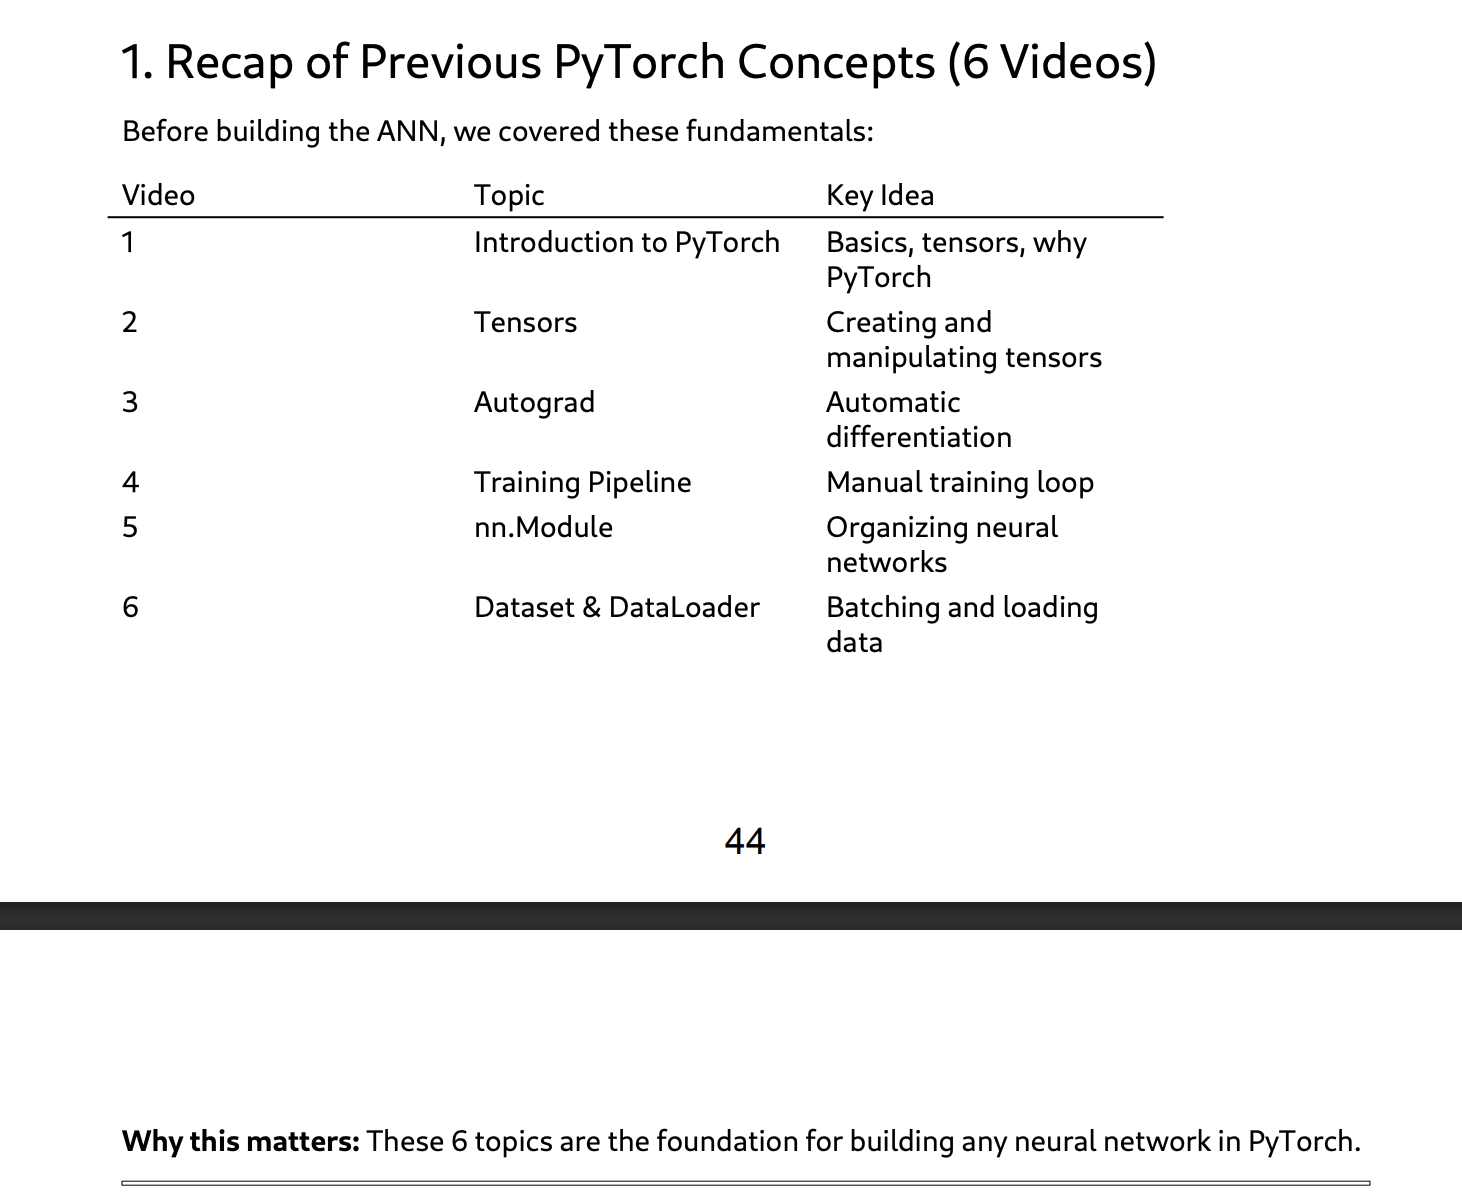

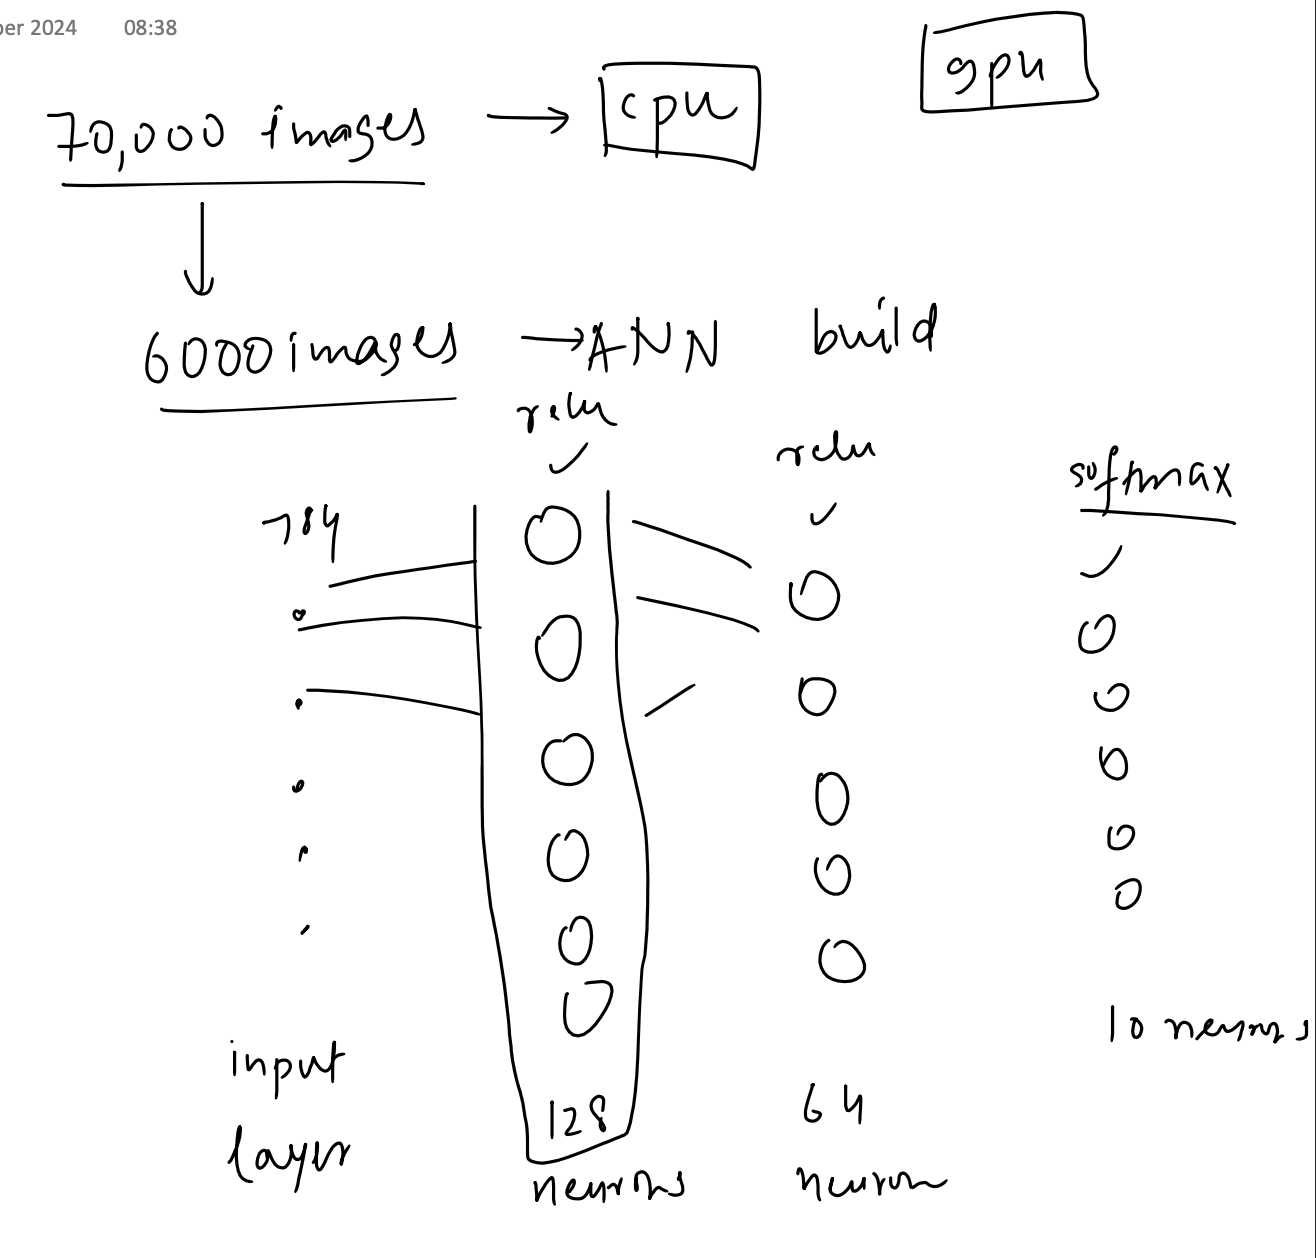

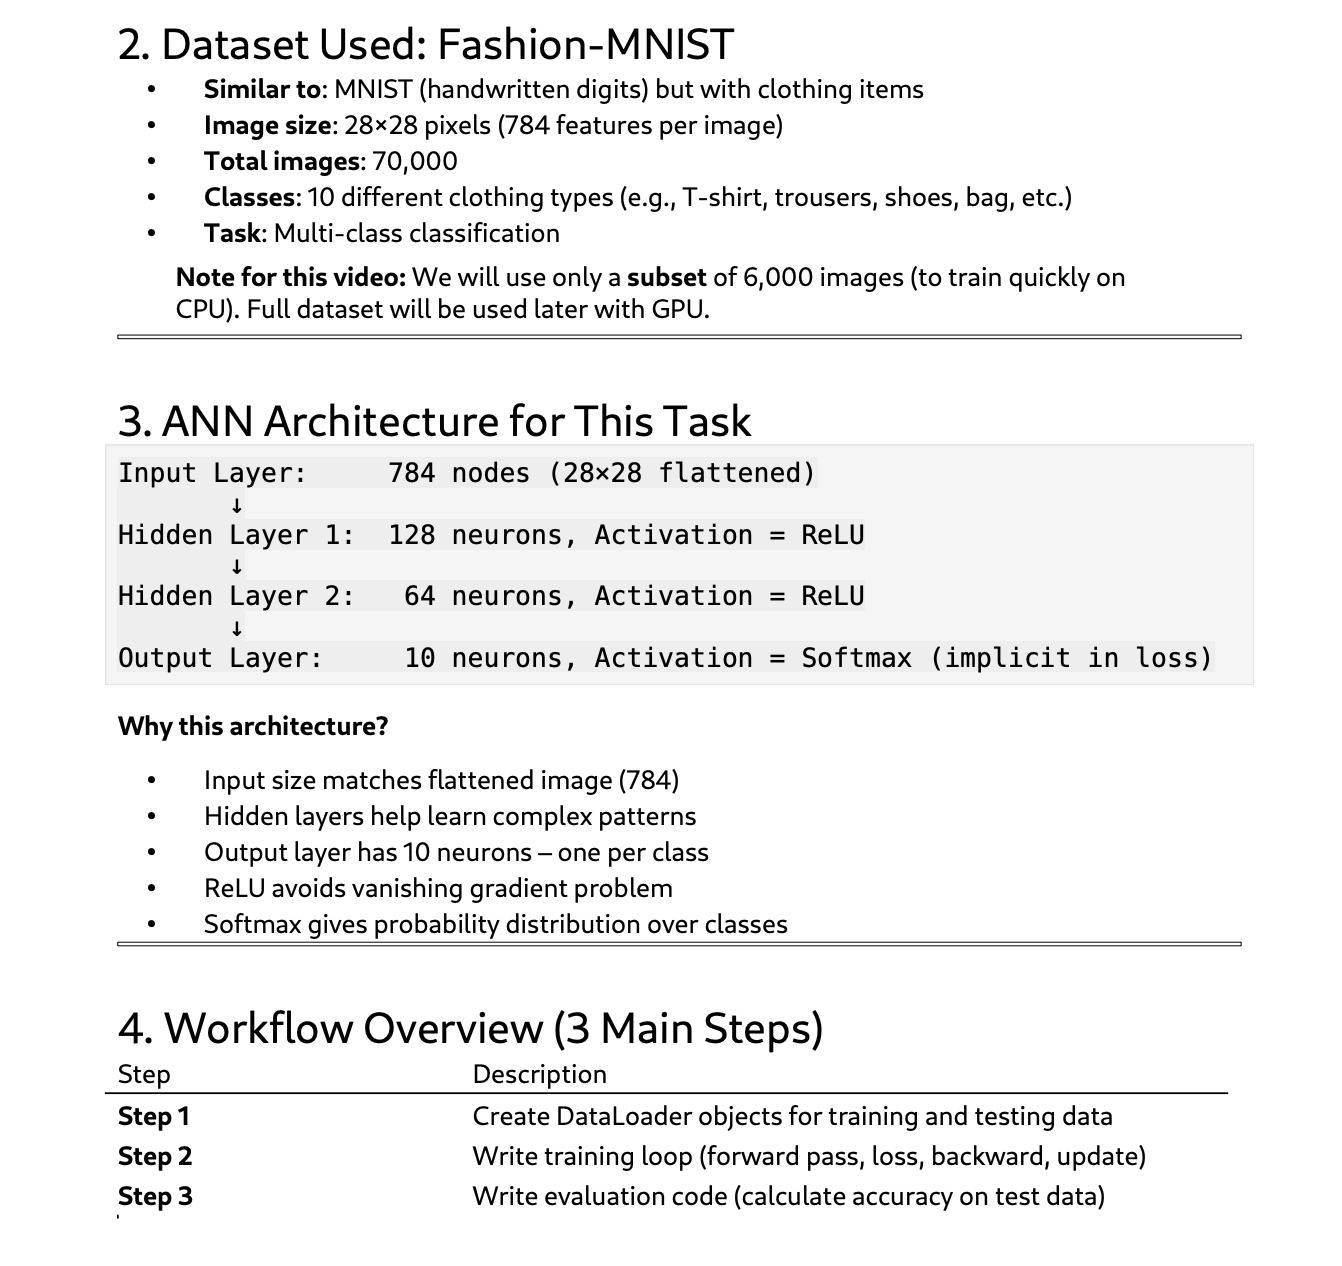

# 5. Detailed Code with Explanations

## 5.1 Import Dependencies and SetSeed (Reproducibility) 

In [2]:
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# set seed for reproducibility
torch.manual_seed(42)

### **Explanation**: Setting a seed ensures that every time you run the code, you get the same random numbers (same weight initialization, same data splits). This makes your results reproducible.

## 5.2 Load and Explore the Data

In [7]:
df=pd.read_csv("./fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


## Two ways to separate X(features) and y(labels)
- using numpy 
- using pandas

In [18]:
# using numpy

## first column = label,next 784 column = pixel values
X=df.iloc[:,1:].values # features (784 columns)
y=df.iloc[:,0].values # labels (0 to 9)
print(X[:4])
print(y[:4])

[[  0   0   0 ... 165   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]
[9 7 0 8]


In [20]:
# using pandas
X=df.drop(["label"],axis="columns").values
y=df["label"].values
print(X[:4])
print(y[:4])

[[  0   0   0 ... 165   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]
[9 7 0 8]


## Optional(for visualizing output)

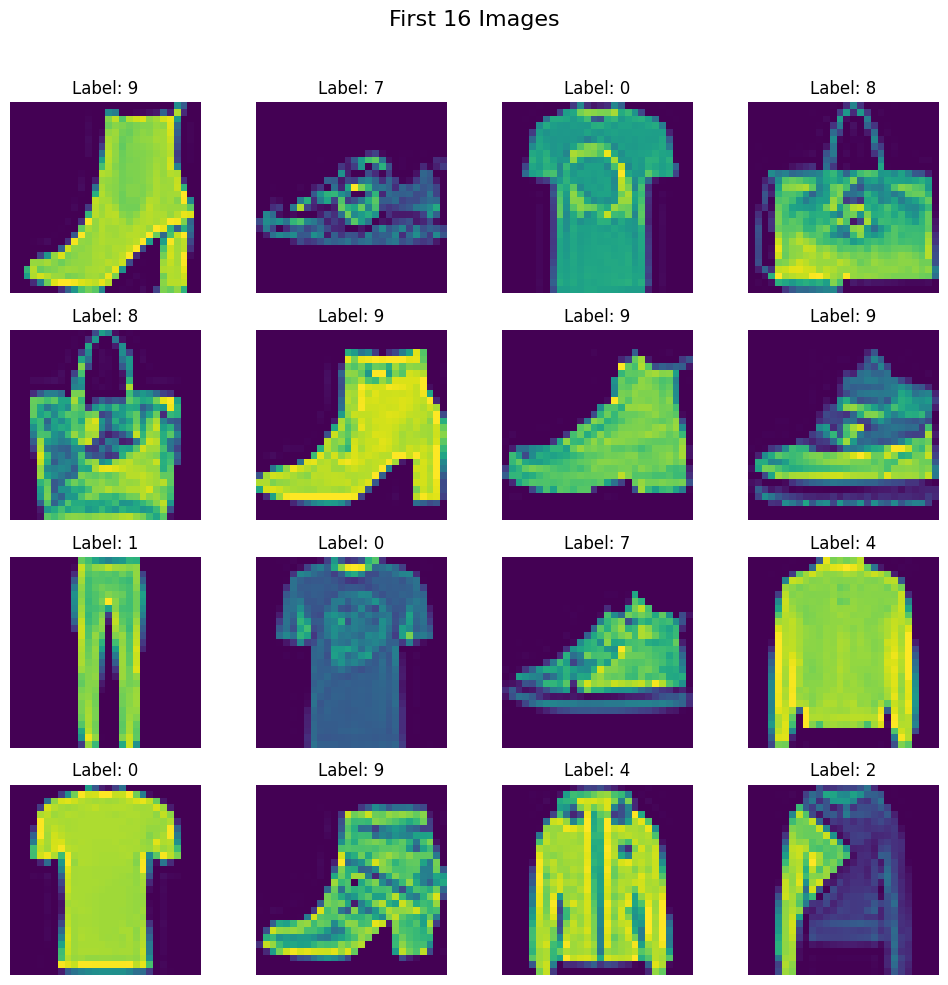

In [8]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


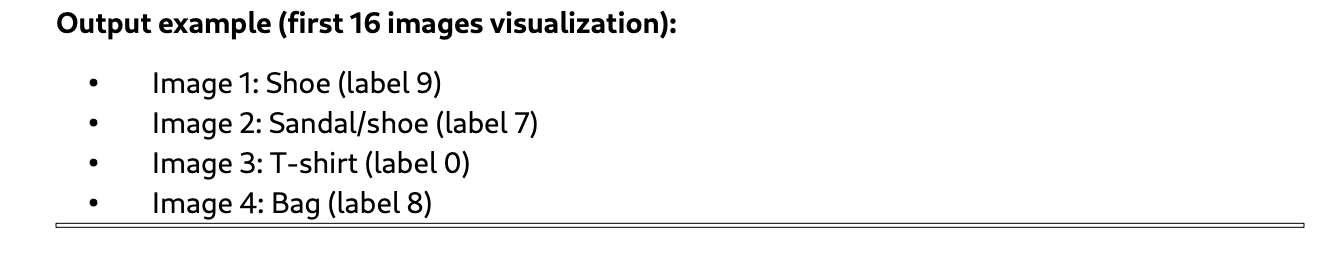

## 5.3 Train-Test Split and Scaling

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Scale pixel value from 0-255 to 0-1 (helps training stability)
X_train=X_train/255.0
X_test=X_test/255.0

print(X_train[:4])


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [24]:
## or Directly use MinMax Scaler ,samething as above approach (/255)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  

print(X_train[:4])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


#### **Why scaling?** Neural networks train more stably when input values are between 0 and 1 (or -1 and 1). Large values (0-255) can cause exploding gradients.

## 5.4 Custom Dataset Class

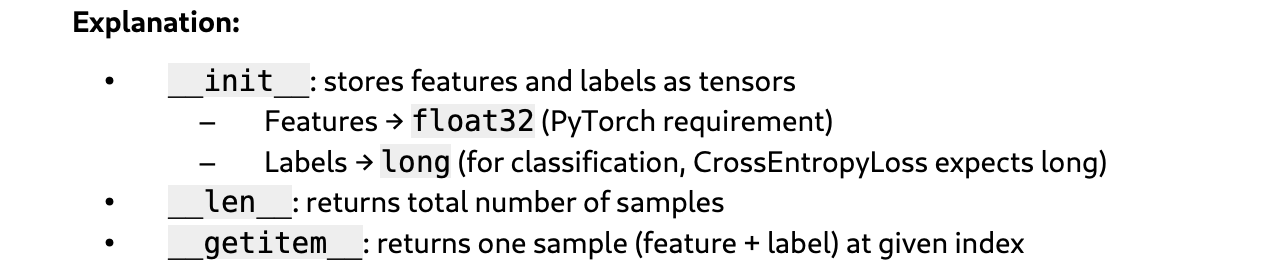

In [26]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        # Convert to Pytorch tensors with correct data types 
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)
    
    def __len__(self):
        # Return total number of samples
        return len(self.features)

    def __getitem__(self,index):
        # Return the sample (features, label) at given index
        # Apply transformations here if needed
        X=self.features[index]
        y=self.labels[index]
        return X,y

In [29]:
## creating dataset objects

# train dataset object
train_dataset=CustomDataset(features=X_train,labels=y_train)
#test dataset object
test_dataset=CustomDataset(features=X_test,labels=y_test)

print(len(train_dataset)) #Output: 4800 (if 6000 total,80% train)
print(train_dataset[0]) #Output : (tensor of 784 pixels ,tensor(7))

4800
(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.

## 5.5 Create DataLoaders (train and test dataloader)
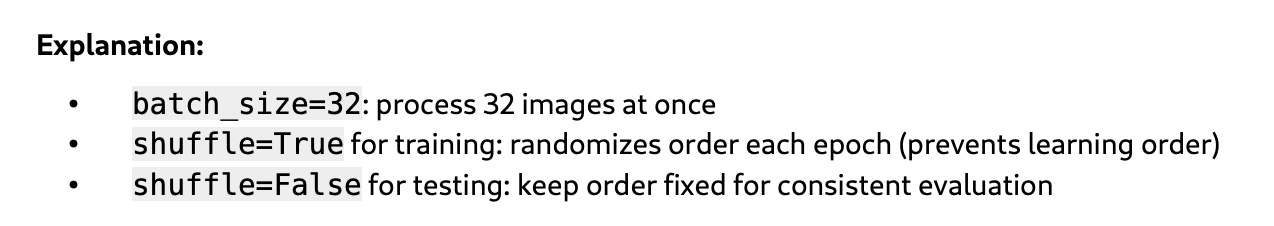

In [32]:
batch_size=32

train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False # very important to set this false
)

print(len(train_loader)) # 4800/32 = 150 batches
print(len(test_loader)) # 1200/32 = 38 batches (20% test)

150
38


Setting shuffle=False during testing is a standard practice in machine learning because shuffling test data does not improve model evaluation and can complicate debugging.
While shuffling is critical during training to prevent the model from learning the order of data or getting stuck in local minima, it is typically disabled during testing for the following reasons:

* No Impact on Performance: Shuffling only affects the order of evaluation, not the final accuracy or loss. Since the model's weights are frozen during testing (inference), the order of samples does not change the mathematical outcome.
* Consistency and Reproducibility: Disabling shuffling ensures that predictions are always in the same order. This makes it easier to compare specific inputs with their corresponding outputs when calculating metrics like confusion matrices or manual error analysis. [2, 7] 
* Debugging: If you encounter an error or an outlier in your test results, having a fixed order allows you to pinpoint exactly which sample caused the issue. 



## 5.6 Define Neural Network Class
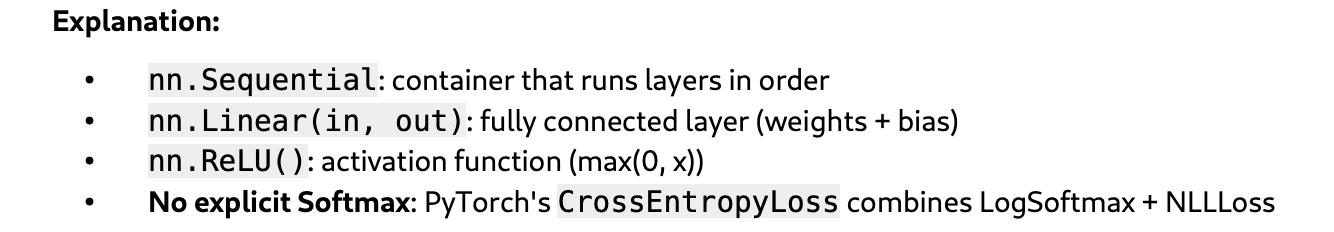

In [36]:
class MyNeuralNet(nn.Module):

    def __init__(self,num_features):

        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(num_features,128), # input ->hidden1
            nn.ReLU(),                  #activation
            nn.Linear(128,64),          # hidden1 -> hidden2
            nn.ReLU(),                  #activation
            nn.Linear(64,10),           #hidden2->output

            # No softmax here  - CrossEntropyLoss applies it internally
        )
    
    def forward(self,x):  # x.features
        out=self.network(x)
        return out

# Instantiate model
input_size=X_train.shape[1] # = 784
model=MyNeuralNet(num_features=input_size)

## 5.7 Loss Function and Optimizer
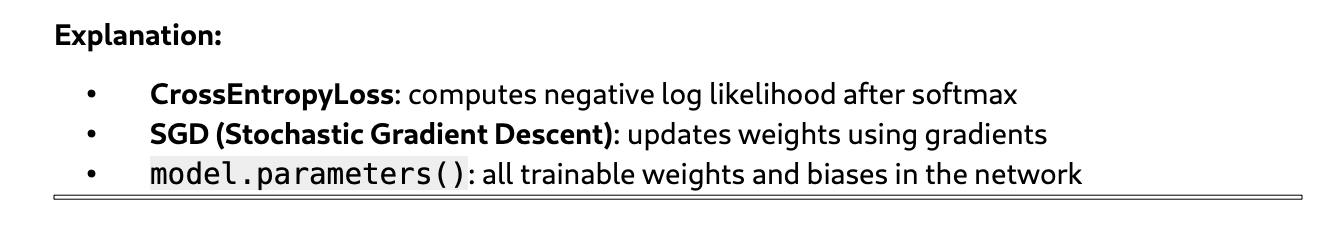

In [ ]:

# loss function
criterion=nn.CrossEntropyLoss() # for multi-class classification

#optimizer
learning_rate=0.01
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

## 5.8 Training Loop
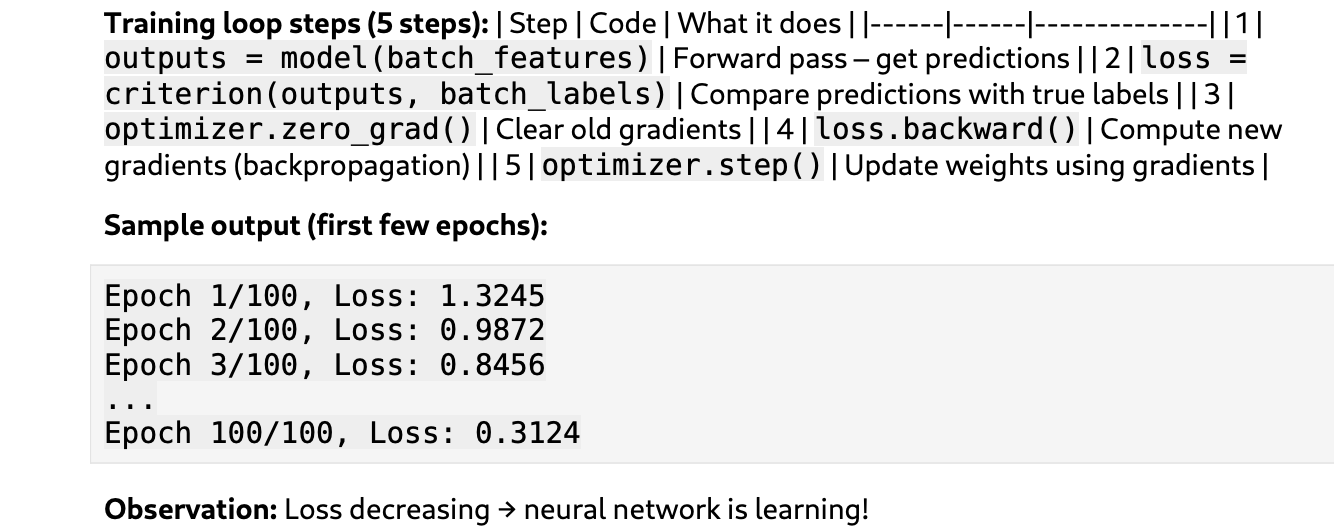

In [41]:
## to find no of batches in training

len(train_loader) # 150 batches

150

In [38]:
epochs=100
num_batches=len(train_loader) # = 150

for epoch in range(epochs):

    total_epoch_loss=0

    for batch_features,batch_labels in train_loader:

        # 1.forward pass : get predictions
        outputs=model(batch_features)

        #2.Calculate loss
        loss=criterion(outputs,batch_labels)

        #3. Clear previous gradients
        optimizer.zero_grad()

        #4.Backward pass (compute gradients)
        loss.backward()

        #5.Update weights
        optimizer.step()


        total_epoch_loss=total_epoch_loss+loss.item()
    
    avg_loss=total_epoch_loss/num_batches
    print(f"Epoch {epoch+1}/{epochs},Loss:{avg_loss:.4f}")



Epoch 1/100,Loss:2.2344
Epoch 2/100,Loss:1.9845
Epoch 3/100,Loss:1.5145
Epoch 4/100,Loss:1.1944
Epoch 5/100,Loss:1.0349
Epoch 6/100,Loss:0.9420
Epoch 7/100,Loss:0.8783
Epoch 8/100,Loss:0.8342
Epoch 9/100,Loss:0.7973
Epoch 10/100,Loss:0.7664
Epoch 11/100,Loss:0.7374
Epoch 12/100,Loss:0.7127
Epoch 13/100,Loss:0.6895
Epoch 14/100,Loss:0.6735
Epoch 15/100,Loss:0.6515
Epoch 16/100,Loss:0.6329
Epoch 17/100,Loss:0.6181
Epoch 18/100,Loss:0.6024
Epoch 19/100,Loss:0.5914
Epoch 20/100,Loss:0.5815
Epoch 21/100,Loss:0.5674
Epoch 22/100,Loss:0.5578
Epoch 23/100,Loss:0.5496
Epoch 24/100,Loss:0.5388
Epoch 25/100,Loss:0.5312
Epoch 26/100,Loss:0.5203
Epoch 27/100,Loss:0.5131
Epoch 28/100,Loss:0.5059
Epoch 29/100,Loss:0.5003
Epoch 30/100,Loss:0.4919
Epoch 31/100,Loss:0.4801
Epoch 32/100,Loss:0.4789
Epoch 33/100,Loss:0.4732
Epoch 34/100,Loss:0.4683
Epoch 35/100,Loss:0.4596
Epoch 36/100,Loss:0.4508
Epoch 37/100,Loss:0.4502
Epoch 38/100,Loss:0.4425
Epoch 39/100,Loss:0.4415
Epoch 40/100,Loss:0.4338
Epoch 41/

## 5.9 Evaluation Code (Accuracy Calculation)
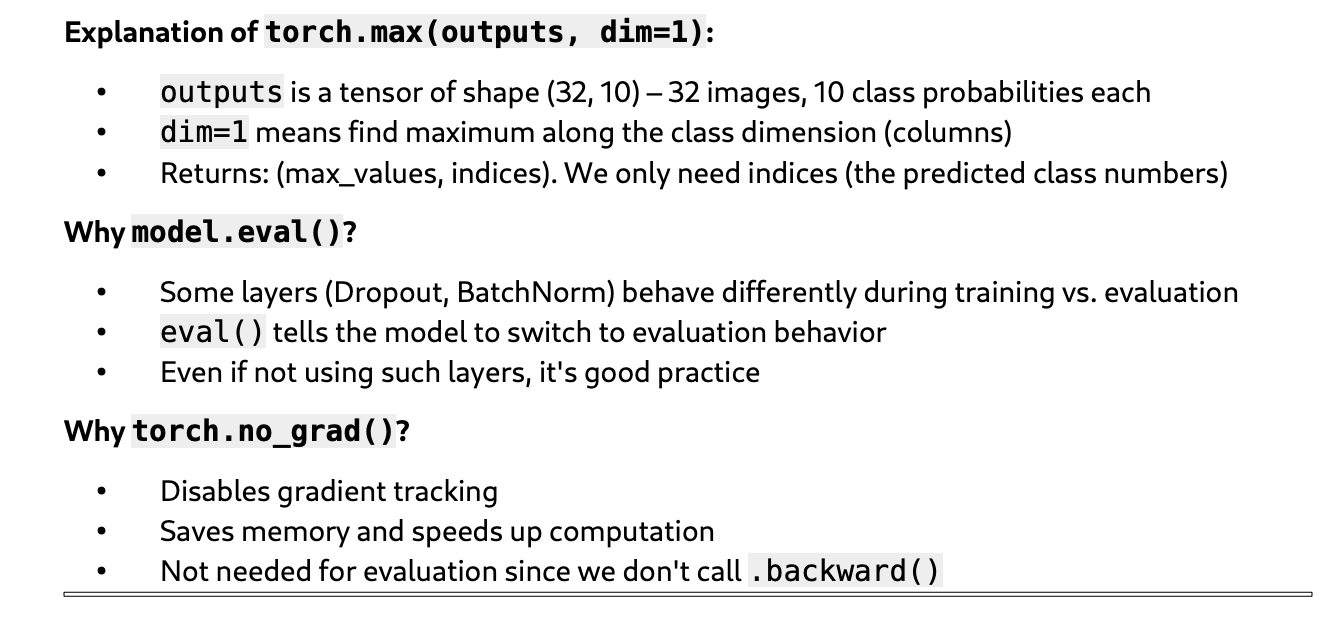

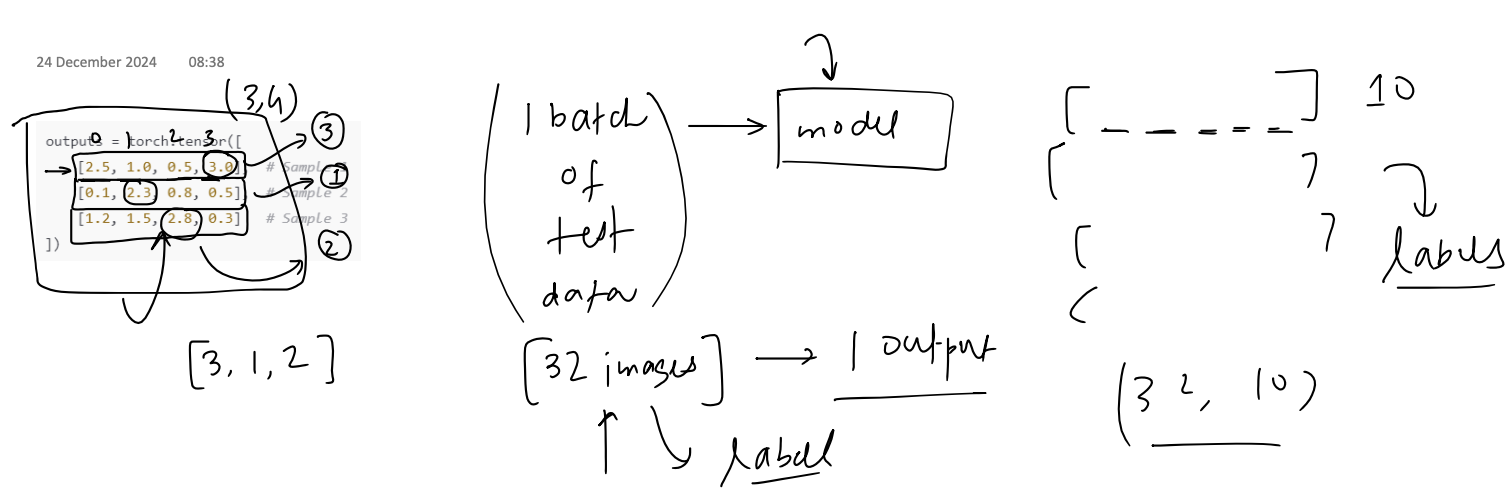

In [ ]:
## to find no of batches in testing

len(test_loader)

38

In [43]:
# set model to evaluation mode
model.eval()

total=0
correct=0

#Disable gradient calculation (saves memory and speed)
with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        #Forward pass
        outputs=model(batch_features)

        #Get predicted class (index with highest probability)
        #outputs shape:(batch_size,10)
        #torch.max returns (values,indices) along dimension 1
        _, predicted = torch.max(outputs,dim=1)

        #Update totals
        total=total+batch_labels.shape[0] # add batch size (32)

        correct=correct+(predicted == batch_labels).sum().item()


print(correct/total)

0.8241666666666667


# COMPLETE CODE (ALL TOGETHER)

In [45]:
# 1. Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split

# 2. Set seed
torch.manual_seed(42)

# 3. Load data
data = pd.read_csv('fmnist_small.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 4. Train-test split & scaling
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
X_train = X_train / 255.0
X_test = X_test / 255.0

# 5. Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# 6. DataLoaders
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 7. Neural Network
class MyNeuralNet(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.model = nn.Sequential(
                        nn.Linear(input_features, 128),
                        nn.ReLU(),
                        nn.Linear(128, 64),
                        nn.ReLU(),
                        nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.model(x)

# 8. Model, Loss, Optimizer
model = MyNeuralNet(784)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 9. Training
epochs = 100
for epoch in range(epochs):
    total_loss = 0
    for features, labels in train_loader:
        outputs = model(features)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss:{total_loss/len(train_loader):.4f}")

# 10. Evaluation
model.eval()
correct = total = 0
with torch.no_grad():
    for features, labels in test_loader:
        outputs = model(features)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy: {100 * correct / total:.2f}%")


Epoch 1, Loss:0.0153
Epoch 1, Loss:0.0307
Epoch 1, Loss:0.0460
Epoch 1, Loss:0.0615
Epoch 1, Loss:0.0769
Epoch 1, Loss:0.0923
Epoch 1, Loss:0.1078
Epoch 1, Loss:0.1230
Epoch 1, Loss:0.1384
Epoch 1, Loss:0.1537
Epoch 1, Loss:0.1691
Epoch 1, Loss:0.1845
Epoch 1, Loss:0.1998
Epoch 1, Loss:0.2152
Epoch 1, Loss:0.2304
Epoch 1, Loss:0.2458
Epoch 1, Loss:0.2610
Epoch 1, Loss:0.2763
Epoch 1, Loss:0.2915
Epoch 1, Loss:0.3067
Epoch 1, Loss:0.3219
Epoch 1, Loss:0.3373
Epoch 1, Loss:0.3525
Epoch 1, Loss:0.3678
Epoch 1, Loss:0.3830
Epoch 1, Loss:0.3981
Epoch 1, Loss:0.4134
Epoch 1, Loss:0.4286
Epoch 1, Loss:0.4439
Epoch 1, Loss:0.4591
Epoch 1, Loss:0.4743
Epoch 1, Loss:0.4896
Epoch 1, Loss:0.5049
Epoch 1, Loss:0.5201
Epoch 1, Loss:0.5353
Epoch 1, Loss:0.5504
Epoch 1, Loss:0.5656
Epoch 1, Loss:0.5808
Epoch 1, Loss:0.5959
Epoch 1, Loss:0.6111
Epoch 1, Loss:0.6264
Epoch 1, Loss:0.6416
Epoch 1, Loss:0.6568
Epoch 1, Loss:0.6720
Epoch 1, Loss:0.6872
Epoch 1, Loss:0.7024
Epoch 1, Loss:0.7174
Epoch 1, Loss

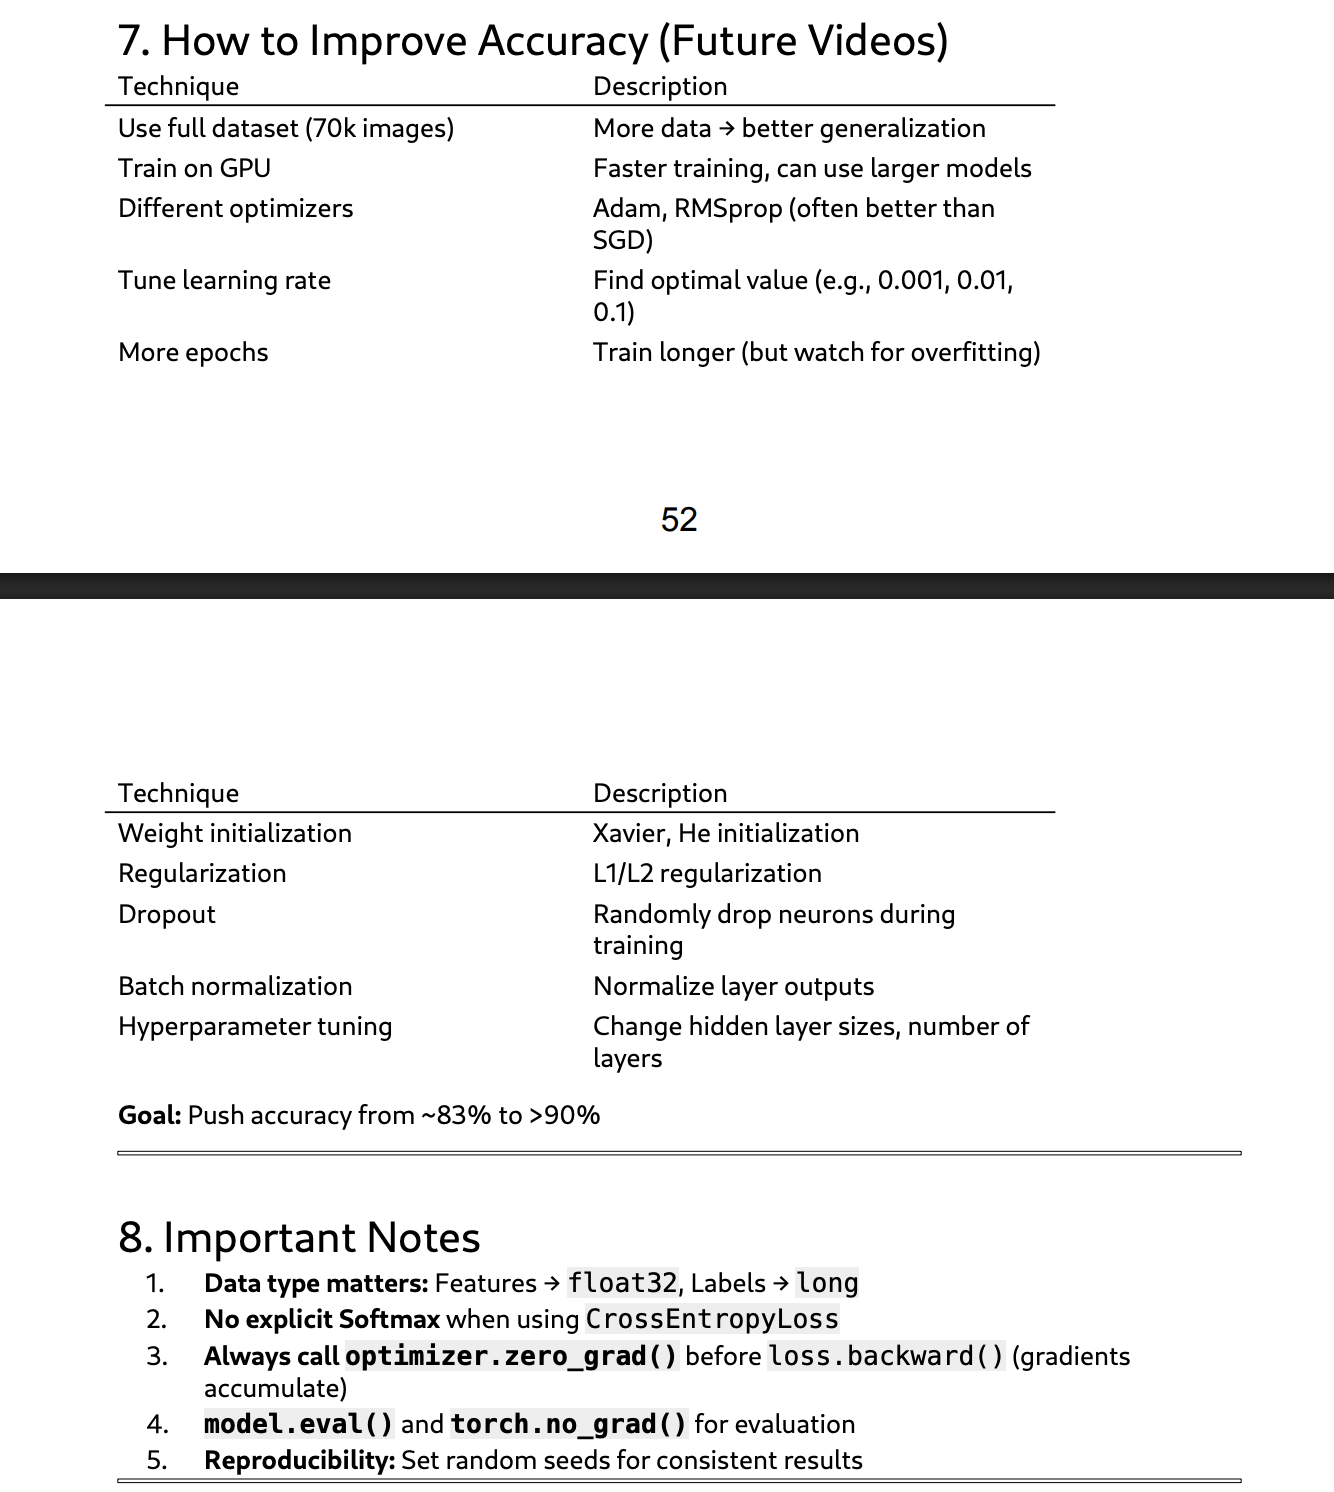